Install dependencies and import libraries

In [ ]:
import os
from glob import glob
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

In [ ]:
!pip install kaggle

!kaggle datasets download -d nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone --unzip -p ./ct_kidney

Dataset URL: https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone
License(s): copyright-authors
100% 1.52G/1.52G [01:49<00:00, 14.8MB/s]



Load images and labels into DataFrame

In [ ]:
dataset_dir = "./ct_kidney"

image_paths = glob(os.path.join(dataset_dir, "**/*.jpg"), recursive=True)
labels = [os.path.basename(os.path.dirname(p)) for p in image_paths]

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
print(df.head())

Total images: 12446
                                          image_path label
0  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst
1  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst
2  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst
3  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst
4  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst


 split dataset

In [ ]:
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.1, stratify=train_df['label'], random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 8960, Val: 996, Test: 2490


 ImageGenerators with augmentation

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

Data Generators

In [ ]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8960 validated image filenames belonging to 4 classes.
Found 996 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.


Build DenseNet121 model

In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Compile Model

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,045,700 (26.88 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

Callbacks

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

Initial Training

In [ ]:
EPOCHS = 10

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

Epoch 1/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 215s 330ms/step - accuracy: 0.7097 - loss: 0.7678 - val_accuracy: 0.8373 - val_loss: 0.4475 - learning_rate: 0.0010
Epoch 2/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 149s 266ms/step - accuracy: 0.7964 - loss: 0.5268 - val_accuracy: 0.8394 - val_loss: 0.4146 - learning_rate: 0.0010
Epoch 3/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 151s 270ms/step - accuracy: 0.8106 - loss: 0.4872 - val_accuracy: 0.8835 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 4/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 146s 261ms/step - accuracy: 0.8217 - loss: 0.4796 - val_accuracy: 0.8896 - val_loss: 0.3189 - learning_rate: 0.0010
Epoch 5/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 144s 258ms/step - accuracy: 0.8225 - loss: 0.4651 - val_accuracy: 0.8584 - val_loss: 0.3583 - learning_rate: 0.0010
Epoch 6/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 202s 257ms/step - accuracy: 0.8177 - loss: 0.4760 - val_accuracy: 0.8675 - val_loss: 0.3442 - learning_rate: 0.0010
Epoch 7/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 145s 259ms/step - accura

In [ ]:

loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc * 100:.2f}%")

156/156 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.9225 - loss: 0.2036
Test Accuracy: 92.25%


Fine-tuning last layers for high accuracy

In [ ]:
base_model.trainable = True

# Freeze early layers, unfreeze last ~20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Fine Tune Training

In [ ]:
FINE_EPOCHS = 10
TOTAL_EPOCHS = EPOCHS + FINE_EPOCHS

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=TOTAL_EPOCHS,
    initial_epoch=EPOCHS,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

Epoch 11/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 201s 304ms/step - accuracy: 0.8365 - loss: 0.4322 - val_accuracy: 0.8996 - val_loss: 0.2828 - learning_rate: 1.0000e-05
Epoch 12/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 147s 262ms/step - accuracy: 0.8413 - loss: 0.4146 - val_accuracy: 0.8986 - val_loss: 0.2757 - learning_rate: 1.0000e-05
Epoch 13/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 148s 264ms/step - accuracy: 0.8449 - loss: 0.4107 - val_accuracy: 0.9026 - val_loss: 0.2654 - learning_rate: 1.0000e-05
Epoch 14/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 147s 263ms/step - accuracy: 0.8549 - loss: 0.3907 - val_accuracy: 0.9026 - val_loss: 0.2655 - learning_rate: 1.0000e-05
Epoch 15/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 148s 264ms/step - accuracy: 0.8612 - loss: 0.3716 - val_accuracy: 0.9076 - val_loss: 0.2485 - learning_rate: 1.0000e-05
Epoch 16/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 146s 261ms/step - accuracy: 0.8633 - loss: 0.3670 - val_accuracy: 0.9207 - val_loss: 0.2291 - learning_rate: 1.0000e-05
Epoch 17/20
560/560 ━━━━━━━━━━━━━━

Evaluate on test set

In [ ]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc * 100:.2f}%")

156/156 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.9313 - loss: 0.1971
Test Accuracy: 93.13%


156/156 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step


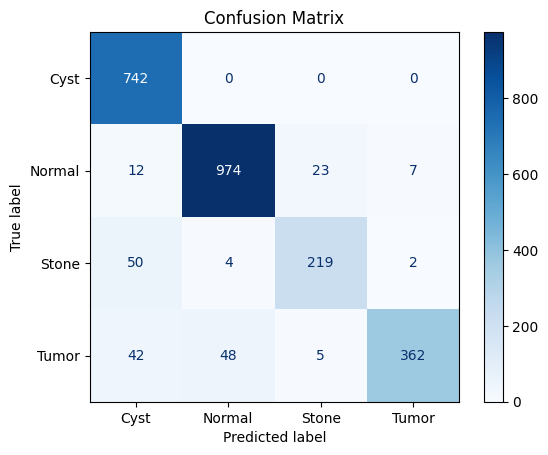

Classification Report:

              precision    recall  f1-score   support

        Cyst       0.88      1.00      0.93       742
      Normal       0.95      0.96      0.95      1016
       Stone       0.89      0.80      0.84       275
       Tumor       0.98      0.79      0.87       457

    accuracy                           0.92      2490
   macro avg       0.92      0.89      0.90      2490
weighted avg       0.93      0.92      0.92      2490



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# 1. Get predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes  # true labels from generator

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(cm, display_labels=test_gen.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# 3. Classification Report
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(test_gen.class_indices.keys())
))

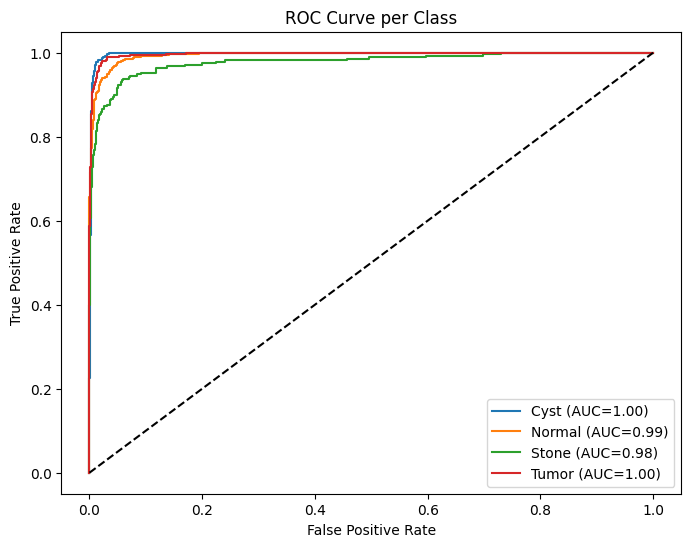

In [ ]:
# --- 2. ROC Curves for Each Class ---
from sklearn.preprocessing import label_binarize

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=list(range(len(test_gen.class_indices))))
plt.figure(figsize=(8,6))

for i, class_name in enumerate(test_gen.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve per Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


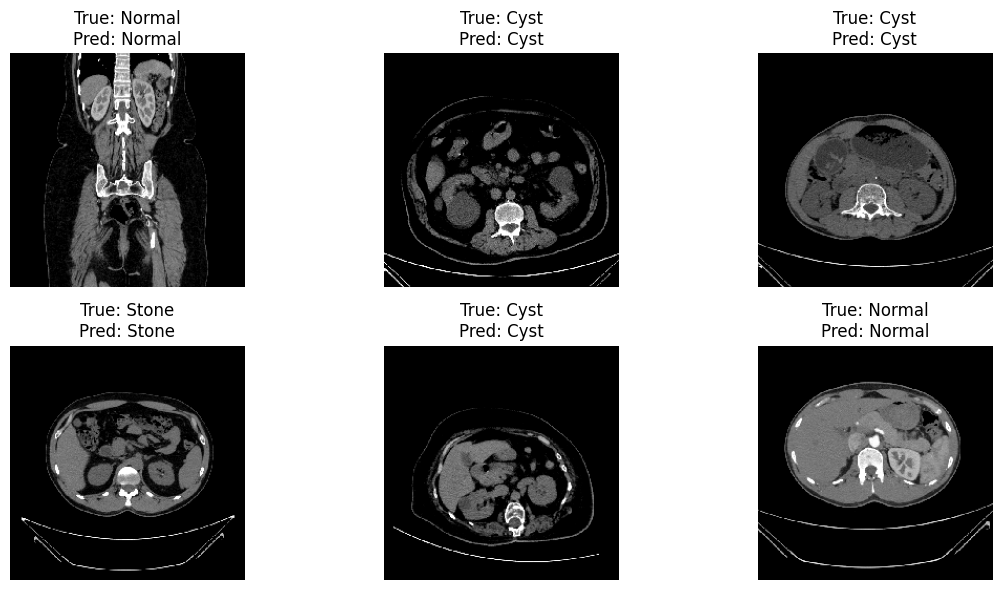

In [ ]:

# Get some sample images from the generator
test_images, test_labels = next(test_gen)  # first batch
pred_classes = np.argmax(model.predict(test_images), axis=1)
true_classes = np.argmax(test_labels, axis=1)

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(test_images[i])
    plt.title(f"True: {list(test_gen.class_indices.keys())[true_classes[i]]}\nPred: {list(test_gen.class_indices.keys())[pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

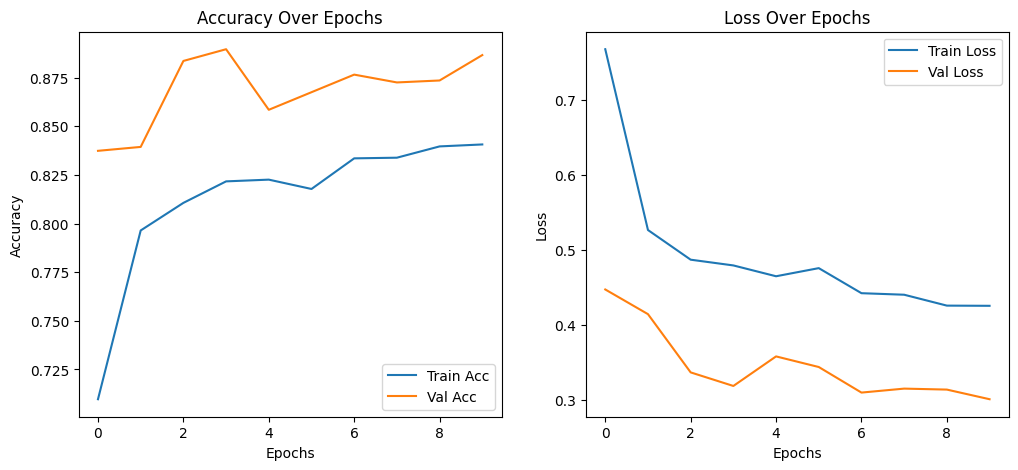

In [ ]:
# Training Curves (Accuracy & Loss)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()

Identifying Last Convulation Layer

In [ ]:
last_conv_layer_name = "conv5_block16_2_conv"

Grad-CAM Function

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        if pred_index is None:
            pred_index = np.argmax(predictions[0].numpy())

        class_channel = predictions[:, pred_index]

    def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

      grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
     )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)

    if max_val != 0:
        heatmap /= max_val

    return heatmap.numpy()

Load Image

In [ ]:
from tensorflow.keras.preprocessing import image
img_path = test_df.iloc[0]['image_path']  # choose any image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

Generate HeatMap

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

Overlay Heatmap

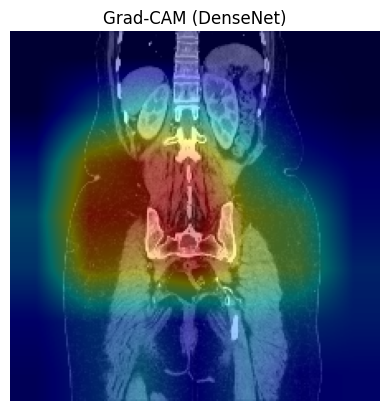

In [ ]:
import cv2
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM (DenseNet)")
plt.show()

#Red/Yellow ->Important regions
#Blue ->Less Important